In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [8]:
# Load Auto MPG dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)
#Display first five rows
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [10]:
#Separate input and output
x = df[['displacement']]
y = df['mpg']
#Check missing values
print("Missing values in ",x.isnull().sum())
print("Missing values in mpg: ",y.isnull().sum())

Missing values in  displacement    0
dtype: int64
Missing values in mpg:  0


In [15]:
#Remove rows containing missing values
data = df[['displacement','mpg']].dropna()

#Update input and output
x = data[['displacement']]
y = data['mpg']

#Display the selected data
print("Feature: ")
print(x.head())

print("\nTarget: ")
print(y.head())

Feature: 
   displacement
0         307.0
1         350.0
2         318.0
3         304.0
4         302.0

Target: 
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


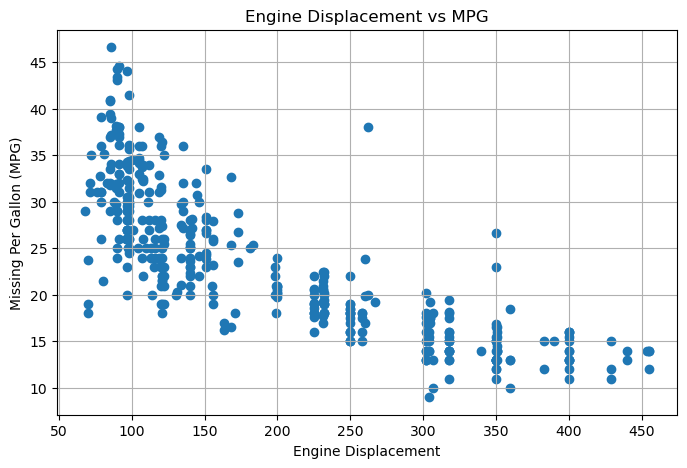

In [19]:
plt.figure(figsize = (8,5))

plt.scatter(x,y)

plt.xlabel("Engine Displacement")
plt.ylabel("Missing Per Gallon (MPG)")
plt.title("Engine Displacement vs MPG")

plt.grid(True)
plt.show()

In [35]:
#Split the dataset
x_train,x_test,y_train,y_test = train_test_split( x, y, test_size = 0.2, random_state = 42)
print("Training samples: ",len(x_train))
print("Testing samples: ",len(x_test))
                                                  

Training samples:  318
Testing samples:  80


In [29]:
#Create Linear regression model
linear_model = LinearRegression()

#Train the model
linear_model.fit(x_train,y_train)

#predict on test data
y_pred_linear = linear_model.predict(x_test)

In [38]:
#Calculate MSE
mse_linear = mean_squared_error(y_test,y_pred_linear)

#calculate R-squared
r2_linear = r2_score(y_test,y_pred_linear)

print("Linear Regression Results")
print("-------------------------")
print("MSE: ",mse_linear)
print("R-squared: ",r2_linear)

Linear Regression Results
-------------------------
MSE:  89.09790232550483
R-squared:  -0.6571284264175425


In [52]:
#Store results
results = []

#Store polynomial models for plotting
polynomial_models = {}

#Add Linear Regression results
results.append({
    'Model':'Linear Regresison', 'Degree':1, 'MSE':mse_linear, 'R-squared':r2_linear})

# Try polynomial degrees from 2 to 5
for degree in range(2,6):
     # Create polynomial features
    poly = PolynomialFeatures(degree=degree)
    # Transform training and testing data
    x_train_poly = poly.fit_transform(x_train)
    x_test_poly = poly.transform(x_test)

    # Create Linear Regression
    poly_model = LinearRegression()
    # Train polynomial regression model
    poly_model.fit(x_train_poly,y_train)
    # Make predictions
    y_pred_poly = poly_model.predict(x_test_poly)
    # Calculate evaluavtion metrics
    mse = mean_squared_error(y_test,y_pred_poly)
    r2 = r2_score(y_test, y_pred_poly)
    # Store results
    results.append({
        'Model':'Polynomial Regression', 'Degree': degree, 'MSE': mse, 'R-squared':r2 })
    # store model and polynomial transformer
    polynomial_models[degree] = {'poly': poly, 'model': poly_model }

# Convert results into DataFrame
results_df = pd.DataFrame(results)

# Display results
results_df

,Model,Degree,MSE,R-squared
0,Linear Regresison,1,89.097902,-0.657128
1,Polynomial Regression,2,15.107354,0.719019
2,Polynomial Regression,3,14.943632,0.722064
3,Polynomial Regression,4,14.961487,0.721732
4,Polynomial Regression,5,15.230896,0.716721


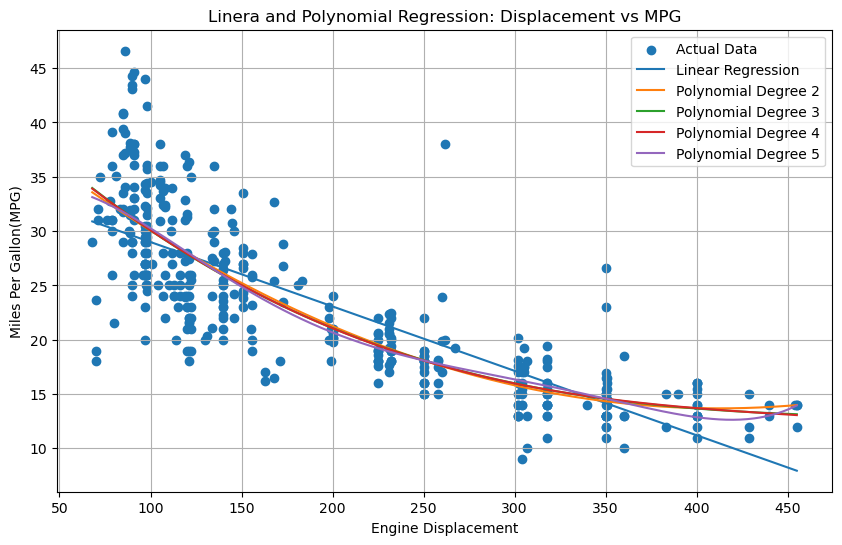

In [68]:
#Create smooth x values for plotting
x_plot = pd.DataFrame({'displacement':np.linspace(x['displacement'].min(),x['displacement'].max(),300)})
#Create Figure
plt.figure(figsize=(10,6))

# Plot actual data 
plt.scatter(x['displacement'],y,label='Actual Data')
y_plot_linear = linear_model.predict(x_plot)
plt.plot(x_plot['displacement'],y_plot_linear,label = 'Linear Regression')
for degree in range(2,6):
    poly = polynomial_models[degree]['poly']
    poly_model = polynomial_models[degree]['model']
    x_plot_poly = poly.transform(x_plot)
    y_plot_ploy = poly_model.predict(x_plot_poly)
    plt.plot(x_plot['displacement'],y_plot_ploy,label = f'Polynomial Degree {degree}')
    plt.xlabel('Engine Displacement')
plt.ylabel('Miles Per Gallon(MPG)')
plt.title('Linera and Polynomial Regression: Displacement vs MPG')
plt.legend()
plt.grid(True)
plt.show()

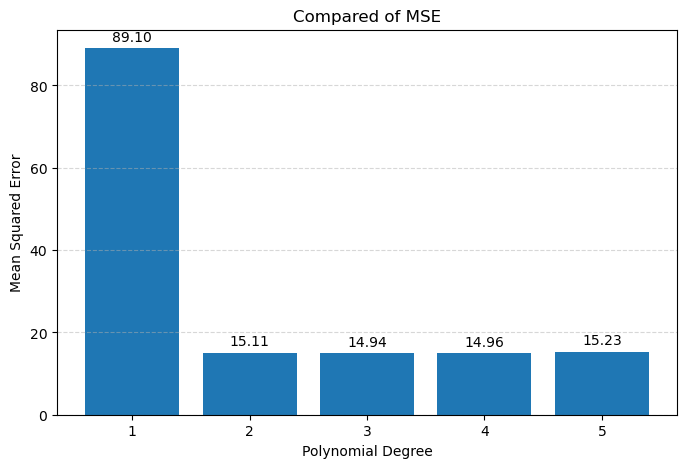

In [71]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
bars = plt.bar(results_df['Degree'].astype(str), results_df['MSE'])
plt.bar_label(bars,fmt='%.2f',padding=3)

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Compared of MSE")
plt.grid(axis = 'y', linestyle='--',alpha=0.5)
plt.show()

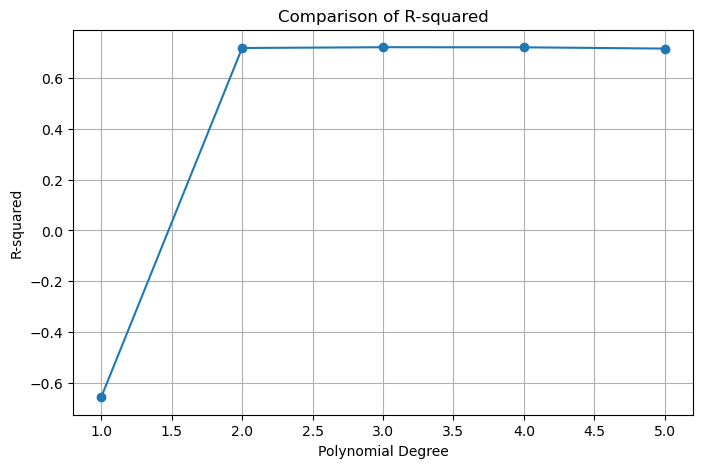

In [72]:
plt.figure(figsize=(8,5))
plt.plot(results_df['Degree'], results_df['R-squared'], marker = 'o')
plt.xlabel("Polynomial Degree")
plt.ylabel("R-squared")
plt.title("Comparison of R-squared")
plt.grid(True)
plt.show()